[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/02_core_deep_learning/06_debugging_and_visualization/debugging.ipynb)


# 06 . Debugging and Visualization

## Concept — Debugging & visualizing training (revision notes)

**What it is**
- A toolbox for answering "why is my network not learning?": loss curves, gradient and activation statistics, hooks to peek inside a model, sanity checks, and plots.
- Neural nets fail silently: a bug usually gives *worse numbers*, not an exception. You find it by measuring.

**Why it matters**
- Most training failures come from a small set of causes: bad learning rate, data/label bugs, wrong train/eval mode, vanishing/exploding gradients, dead units, or NaNs. Each leaves a recognizable fingerprint in the right plot.

**When to use**
- Before every long run (cheap sanity checks), when a loss curve looks odd, and whenever you change an architecture or initialization.

**Math & intuition**
- A randomly initialized classifier with `C` classes should start near loss `ln(C)`; a very different start means a bug in the loss, labels or output scaling.
- A model must be able to **overfit a single small batch** to ~0 loss. If it cannot, the problem is in the code, not the data.
- Healthy update-to-weight ratio is roughly `lr * |grad| / |w| ~ 1e-3`; far above means instability, far below means almost no learning.
- Forward hooks see activations (`module, input, output`); backward hooks see gradients w.r.t. module inputs/outputs; `tensor.register_hook` sees the gradient of one tensor.
- Train/val gap: both high = underfitting; train low, val high = overfitting; both noisy = learning rate/batch size issue.


### 1. A toy problem and a logger

**What this cell does (plain language):** we create a 3-class 2D spiral dataset (generated in-notebook), define a small MLP, and a `fit` function that records train loss, validation loss and gradient norm every epoch into a dictionary. Everything later reuses this logging pattern.

In [1]:
import math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)

def spiral(n_per_class, seed, noise=0.2):
    g = torch.Generator().manual_seed(seed)
    xs, ys = [], []
    for c in range(3):
        r = torch.linspace(0.2, 1.0, n_per_class)
        th = torch.linspace(c * 2.1, c * 2.1 + 3.5, n_per_class) + noise * torch.randn(n_per_class, generator=g)
        xs.append(torch.stack([r * torch.sin(th), r * torch.cos(th)], 1)); ys.append(torch.full((n_per_class,), c))
    return torch.cat(xs), torch.cat(ys)

Xtr, ytr = spiral(100, 0); Xva, yva = spiral(100, 1)
print("train", tuple(Xtr.shape), "val", tuple(Xva.shape), "| ln(3) =", round(math.log(3), 3))

def make_mlp(width=32, depth=2, act=nn.ReLU):
    layers, d = [], 2
    for _ in range(depth):
        layers += [nn.Linear(d, width), act()]; d = width
    return nn.Sequential(*layers, nn.Linear(d, 3))

def total_grad_norm(model):
    return math.sqrt(sum(p.grad.pow(2).sum().item() for p in model.parameters() if p.grad is not None))

def fit(model, epochs=100, lr=0.05, X=Xtr, y=ytr, Xv=Xva, yv=yva, opt_cls=torch.optim.SGD, **opt_kw):
    opt = opt_cls(model.parameters(), lr=lr, **opt_kw)
    log = {"train": [], "val": [], "gnorm": []}
    for ep in range(epochs):
        model.train()
        opt.zero_grad(); loss = F.cross_entropy(model(X), y); loss.backward()
        log["gnorm"].append(total_grad_norm(model))       # measure BEFORE step (and before any clipping)
        opt.step()
        model.eval()
        with torch.no_grad(): log["val"].append(F.cross_entropy(model(Xv), yv).item())
        log["train"].append(loss.item())
    return log

torch.manual_seed(0)
log = fit(make_mlp(), epochs=200, lr=0.1, momentum=0.9)
print(f"final train {log['train'][-1]:.3f} | val {log['val'][-1]:.3f}")

train (300, 2) val (300, 2) | ln(3) = 1.099


final train 0.012 | val 0.016


### 2. Plotting loss curves (and smoothing noisy ones)

**What this cell does (plain language):** we plot train/validation loss and the gradient norm side by side. We also show an exponential moving average (EMA) which is how most dashboards smooth noisy per-batch losses; note the smoothed curve lags the raw one.

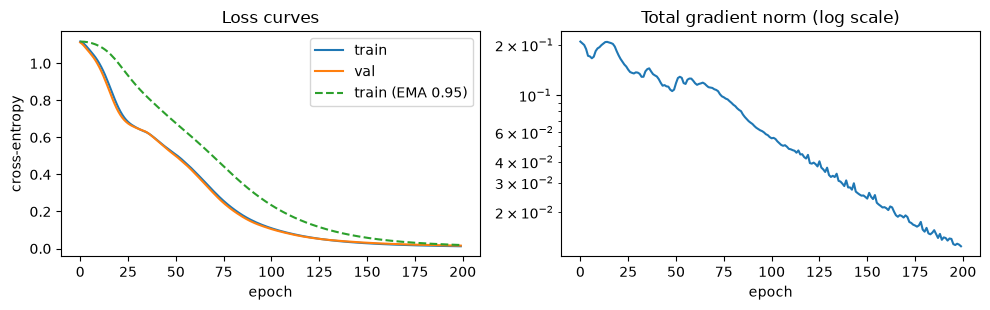

In [2]:
def ema(xs, beta=0.9):
    out, m = [], xs[0]
    for x in xs:
        m = beta * m + (1 - beta) * x; out.append(m)
    return out

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(log["train"], label="train"); ax[0].plot(log["val"], label="val")
ax[0].plot(ema(log["train"], 0.95), "--", label="train (EMA 0.95)")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy"); ax[0].set_title("Loss curves"); ax[0].legend()
ax[1].semilogy(log["gnorm"]); ax[1].set_xlabel("epoch"); ax[1].set_title("Total gradient norm (log scale)")
plt.tight_layout(); plt.show()

### 3. Sanity check 1: the initial loss, and overfit one batch

**What this cell does (plain language):** two checks you should run before any long training. (a) At initialization the loss should be about `ln(C)`. (b) The model should be able to drive the loss to almost zero on a single tiny batch. We also show the classic failure of (a): a loss scaled wrongly at the output.

In [3]:
torch.manual_seed(0)
model = make_mlp()
with torch.no_grad(): init_loss = F.cross_entropy(model(Xtr), ytr).item()
print(f"initial loss {init_loss:.3f} vs ln(3) = {math.log(3):.3f}  -> {'OK' if abs(init_loss - math.log(3)) < 0.3 else 'SUSPICIOUS'}")

# a model with huge output weights starts very confident and wrong -> much higher initial loss
bad = make_mlp()
with torch.no_grad(): bad[-1].weight.mul_(30)
with torch.no_grad(): print(f"oversized final layer: initial loss {F.cross_entropy(bad(Xtr), ytr).item():.2f}  (>> ln(3): fix init/scale)")

# overfit a single batch of 8 examples
xb, yb = Xtr[::40][:8], ytr[::40][:8]
opt = torch.optim.Adam(model.parameters(), lr=0.01)
for step in range(300):
    opt.zero_grad(); loss = F.cross_entropy(model(xb), yb); loss.backward(); opt.step()
print(f"after 300 steps on one batch: loss {loss.item():.5f}  (should be ~0; if not, there is a bug)")

initial loss 1.118 vs ln(3) = 1.099  -> OK
oversized final layer: initial loss 2.15  (>> ln(3): fix init/scale)


after 300 steps on one batch: loss 0.00041  (should be ~0; if not, there is a bug)


### 4. Learning-rate sweep: reading the fingerprints

**What this cell does (plain language):** we train the same model with learning rates over several orders of magnitude and plot the curves. Too small: flat. Good: smooth descent. Too large: oscillation, a plateau at a bad value, or divergence to NaN. This is the single most common cause of a bad loss curve.

lr=0.0001  final train loss = 1.1173


lr=0.001   final train loss = 1.1135


lr=0.01    final train loss = 1.0804


lr=0.1     final train loss = 0.7340


lr=1.0     final train loss = 0.2180


lr=10.0    final train loss = 1.6172


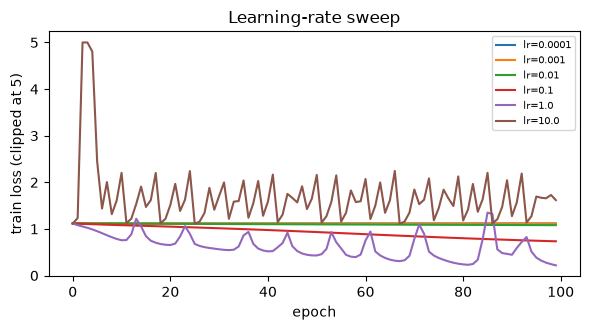

In [4]:
lrs = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
plt.figure(figsize=(6, 3.4))
for lr in lrs:
    torch.manual_seed(0)
    lg = fit(make_mlp(), epochs=100, lr=lr)
    final = lg["train"][-1]
    print(f"lr={lr:<7} final train loss = {final:.4f}" + ("  (non-finite!)" if not math.isfinite(final) else ""))
    plt.plot([min(l, 5) for l in lg["train"]], label=f"lr={lr}")      # clip for plotting only
plt.xlabel("epoch"); plt.ylabel("train loss (clipped at 5)"); plt.legend(fontsize=7); plt.title("Learning-rate sweep"); plt.tight_layout(); plt.show()

### 5. Overfitting vs underfitting: the train/val gap

**What this cell does (plain language):** we fit a big MLP to a tiny training set (30 points) and a tiny linear model to the full data, then plot both. Large model + little data: train loss falls to ~0 while validation loss rises or stalls (a gap). Too-small model: both stay high (underfit). The remedies differ (regularize/more data vs bigger model), so you must read the curves first.

overfit (big model, 30 pts)  train 0.001 | val 0.722 | best val 0.452 at epoch 73
underfit (linear model)      train 0.687 | val 0.690 | best val 0.690 at epoch 299


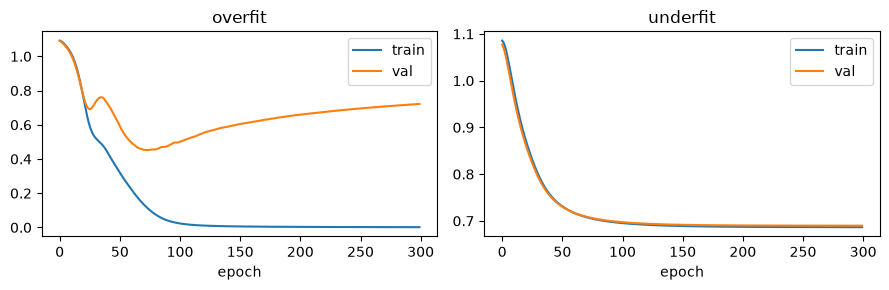

In [5]:
Xs, ys = Xtr[::10], ytr[::10]                      # only 30 training points
torch.manual_seed(0)
over = fit(make_mlp(128, 3), epochs=300, lr=0.05, X=Xs, y=ys, momentum=0.9)
torch.manual_seed(0)
under = fit(nn.Linear(2, 3), epochs=300, lr=0.05, momentum=0.9)       # linear model cannot separate spirals
for name, lg in (("overfit (big model, 30 pts)", over), ("underfit (linear model)", under)):
    print(f"{name:28s} train {lg['train'][-1]:.3f} | val {lg['val'][-1]:.3f} | best val {min(lg['val']):.3f} at epoch {lg['val'].index(min(lg['val']))}")
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
for a, (name, lg) in zip(ax, (("overfit", over), ("underfit", under))):
    a.plot(lg["train"], label="train"); a.plot(lg["val"], label="val"); a.set_title(name); a.set_xlabel("epoch"); a.legend()
plt.tight_layout(); plt.show()

### 6. Per-layer gradient norms: spotting vanishing gradients

**What this cell does (plain language):** we build a 10-layer sigmoid network (a classic vanishing-gradient setup) and a 10-layer ReLU network with He initialization, run one backward pass, and print/plot the gradient norm of each layer's weight. A healthy network shows similar magnitudes across depth; a vanishing one shows early layers with gradients orders of magnitude smaller.

 layer |  sigmoid net |  relu+He net
     0 |     5.70e-10 |     4.83e-02
     2 |     1.60e-08 |     2.15e-01
     4 |     8.64e-08 |     2.51e-01
     6 |     7.91e-07 |     2.18e-01
     8 |     7.64e-06 |     2.86e-01
    10 |     4.51e-05 |     1.92e-01
    12 |     3.80e-04 |     2.31e-01
    14 |     2.30e-03 |     3.28e-01
    16 |     1.68e-02 |     2.52e-01
    18 |     1.01e-01 |     3.04e-01
    20 |     6.83e-01 |     2.76e-01


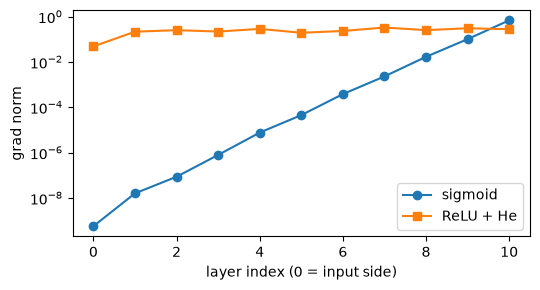

In [6]:
def layer_grad_norms(model, X=Xtr, y=ytr):
    model.zero_grad()
    F.cross_entropy(model(X), y).backward()
    return {n: p.grad.norm().item() for n, p in model.named_parameters() if n.endswith("weight")}

torch.manual_seed(0)
sig = make_mlp(width=32, depth=10, act=nn.Sigmoid)
torch.manual_seed(0)
relu = make_mlp(width=32, depth=10, act=nn.ReLU)
for m in relu:
    if isinstance(m, nn.Linear): nn.init.kaiming_normal_(m.weight, nonlinearity="relu"); nn.init.zeros_(m.bias)

g_sig, g_relu = layer_grad_norms(sig), layer_grad_norms(relu)
print(f"{'layer':>6} | {'sigmoid net':>12} | {'relu+He net':>12}")
for (n, a), (_, b) in zip(g_sig.items(), g_relu.items()):
    print(f"{n.split('.')[0]:>6} | {a:12.2e} | {b:12.2e}")
plt.figure(figsize=(5.5, 3)); plt.semilogy(list(g_sig.values()), "o-", label="sigmoid"); plt.semilogy(list(g_relu.values()), "s-", label="ReLU + He")
plt.xlabel("layer index (0 = input side)"); plt.ylabel("grad norm"); plt.legend(); plt.tight_layout(); plt.show()

### 7. Forward hooks: activation statistics per layer

**What this cell does (plain language):** a *forward hook* is a function PyTorch calls after a module runs, receiving `(module, inputs, output)`. We register hooks on every ReLU to record the mean, std and the fraction of exactly-zero outputs (dead units), then remove the hooks. Hooks let you inspect any model without editing its code.

In [7]:
def attach_activation_stats(model, layer_types=(nn.ReLU,)):
    stats, handles = {}, []
    for name, mod in model.named_modules():
        if isinstance(mod, layer_types):
            def hook(m, inp, out, name=name):                      # default arg captures the loop variable
                stats[name] = dict(mean=out.mean().item(), std=out.std().item(), dead=(out == 0).float().mean().item())
            handles.append(mod.register_forward_hook(hook))
    return stats, handles

stats, handles = attach_activation_stats(relu)
with torch.no_grad(): relu(Xtr)
for h in handles: h.remove()                                       # ALWAYS remove hooks you no longer need
print(f"{'layer':>6} | {'mean':>7} | {'std':>7} | {'dead frac':>9}")
for n, s in stats.items(): print(f"{n:>6} | {s['mean']:7.3f} | {s['std']:7.3f} | {s['dead']:9.3f}")

# dead ReLU demo: a hugely negative bias kills a layer's units
dead_net = make_mlp(depth=2)
with torch.no_grad(): dead_net[0].bias.fill_(-50.0)
stats2, handles2 = attach_activation_stats(dead_net)
with torch.no_grad(): dead_net(Xtr)
for h in handles2: h.remove()
print("after setting bias=-50, dead fraction at first ReLU:", stats2["1"]["dead"])

 layer |    mean |     std | dead frac
     1 |   0.259 |   0.401 |     0.496
     3 |   0.196 |   0.340 |     0.527
     5 |   0.120 |   0.266 |     0.648
     7 |   0.133 |   0.257 |     0.533
     9 |   0.153 |   0.242 |     0.479
    11 |   0.149 |   0.233 |     0.465
    13 |   0.140 |   0.296 |     0.572
    15 |   0.128 |   0.259 |     0.532
    17 |   0.115 |   0.235 |     0.553
    19 |   0.131 |   0.227 |     0.414
after setting bias=-50, dead fraction at first ReLU: 1.0


### 8. Backward hooks and tensor hooks: looking at (and modifying) gradients

**What this cell does (plain language):** `register_full_backward_hook` gives you the gradients flowing through a module, and `tensor.register_hook` the gradient of one tensor - and a hook may *return* a new gradient. We record the gradient reaching each Linear layer's output and then use a tensor hook to zero-out part of a gradient to show hooks can change training.

In [8]:
grads_seen = {}
net = make_mlp(depth=3)
handles = []
for name, mod in net.named_modules():
    if isinstance(mod, nn.Linear):
        # grad_output[0] is d loss / d (this layer's output)
        handles.append(mod.register_full_backward_hook(
            lambda m, gi, go, name=name: grads_seen.__setitem__(name, go[0].abs().mean().item())))
xin = Xtr.clone().requires_grad_(True)       # input requires grad -> hook fires on module inputs too (no warning)
F.cross_entropy(net(xin), ytr).backward()
for h in handles: h.remove()
print("mean |dL/d(output)| per Linear layer (from the loss backwards):", {k: round(v, 5) for k, v in grads_seen.items()})

# tensor hook: zero the gradient of the second input feature
x = Xtr[:5].clone().requires_grad_(True)
x.register_hook(lambda g: g * torch.tensor([1.0, 0.0]))        # returned tensor REPLACES the gradient
net(x).sum().backward()
print("grad wrt inputs (column 1 was zeroed by the hook):\n", x.grad)

# parameter hook = per-parameter gradient clipping/scaling
p = net[0].weight
h = p.register_hook(lambda g: g.clamp(-0.01, 0.01)); net.zero_grad()
F.cross_entropy(net(Xtr), ytr).backward(); h.remove()
print("max |grad| of first weight after clamp hook:", p.grad.abs().max().item())

mean |dL/d(output)| per Linear layer (from the loss backwards): {'6': 0.00148, '4': 0.00015, '2': 6e-05, '0': 2e-05}
grad wrt inputs (column 1 was zeroed by the hook):
 tensor([[0.0474, -0.0000],
        [0.0474, -0.0000],
        [0.0474, -0.0000],
        [0.0496, -0.0000],
        [0.0558, -0.0000]])
max |grad| of first weight after clamp hook: 0.004639751743525267


### 9. Update-to-weight ratio

**What this cell does (plain language):** a rule of thumb for judging the learning rate per layer is the ratio `|lr * grad| / |weight|`; about 1e-3 is healthy. We train for a few steps with three learning rates and print the ratio for each layer, which complements the loss curve by telling you which *layer* is moving too fast or too slow.

In [9]:
def update_ratios(lr, steps=20):
    torch.manual_seed(0)
    net = make_mlp(depth=3); opt = torch.optim.SGD(net.parameters(), lr=lr)
    ratios = {}
    for _ in range(steps):
        opt.zero_grad(); F.cross_entropy(net(Xtr), ytr).backward()
        for n, p in net.named_parameters():
            if n.endswith("weight"): ratios[n] = (lr * p.grad.norm() / p.norm()).item()
        opt.step()
    return ratios

print(f"{'lr':>6} | " + " | ".join(f"{n.split('.')[0]:>9}" for n in update_ratios(0.1)))
for lr in (0.001, 0.1, 1.0):
    r = update_ratios(lr)
    print(f"{lr:>6} | " + " | ".join(f"{v:9.1e}" for v in r.values()))
print("target is roughly 1e-3: much smaller = barely learning, much larger = unstable")

    lr |         0 |         2 |         4 |         6
 0.001 |   3.7e-06 |   1.9e-05 |   1.5e-05 |   5.4e-05
   0.1 |   3.9e-04 |   1.5e-03 |   1.3e-03 |   3.9e-03
   1.0 |   2.4e-02 |   8.6e-02 |   5.9e-02 |   1.1e-01
target is roughly 1e-3: much smaller = barely learning, much larger = unstable


### 10. Data and mode bugs that look like model bugs

**What this cell does (plain language):** three experiments where the *code runs fine* but the result is wrong: (a) shuffled labels cannot be learned beyond memorization, so a model that reaches low validation loss on shuffled labels signals leakage; (b) forgetting `model.eval()` with dropout gives noisy, different predictions on the same input; (c) a missing `zero_grad()` makes gradients accumulate.

In [10]:
# (a) label shuffling test: train loss may fall by memorizing, but validation loss cannot beat chance
torch.manual_seed(0)
perm_y = ytr[torch.randperm(len(ytr))]
lg = fit(make_mlp(128, 3), epochs=200, lr=0.05, y=perm_y, momentum=0.9)
print(f"(a) shuffled labels: train loss {lg['train'][-1]:.3f}, val loss {lg['val'][-1]:.3f} (chance = {math.log(3):.3f}) -> val stays near/above chance")

# (b) eval vs train mode with dropout
torch.manual_seed(0)
dnet = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Dropout(0.5), nn.Linear(16, 3))
x = Xva[:4]
dnet.train(); a, b = dnet(x), dnet(x)
dnet.eval();  c, d = dnet(x), dnet(x)
print("(b) train mode: two passes identical?", torch.allclose(a, b), "| eval mode:", torch.allclose(c, d))

# (c) missing zero_grad
net = nn.Linear(2, 3); xb, yb = Xtr[:16], ytr[:16]
F.cross_entropy(net(xb), yb).backward(); g1 = net.weight.grad.clone()
F.cross_entropy(net(xb), yb).backward(); g2 = net.weight.grad.clone()          # no zero_grad in between
print("(c) gradient doubled without zero_grad:", torch.allclose(g2, 2 * g1))

(a) shuffled labels: train loss 1.057, val loss 1.181 (chance = 1.099) -> val stays near/above chance
(b) train mode: two passes identical? False | eval mode: True
(c) gradient doubled without zero_grad: True


### 11. Detecting NaNs: anomaly mode and finite checks

**What this cell does (plain language):** when the loss turns NaN you need to find the *first* operation that produced it. `torch.autograd.set_detect_anomaly(True)` makes `backward` raise at the op that created a NaN gradient and shows where the forward op was called (slow, so only for debugging). A cheap alternative is to assert `torch.isfinite` on tensors yourself.

In [11]:
x = torch.tensor([1.0, 0.0, 2.0], requires_grad=True)

# sqrt(0) is finite in the forward pass but its gradient is inf -> NaN downstream
def buggy(x): return (torch.sqrt(x) * 0.0).sum()      # 0 * inf = NaN in backward

buggy(x).backward()
print("without anomaly mode, grad is silently:", x.grad)

x.grad = None
import warnings
with warnings.catch_warnings(), torch.autograd.set_detect_anomaly(True):
    warnings.simplefilter("ignore")                  # anomaly mode also prints the forward traceback as a warning
    try:
        buggy(x).backward()
    except RuntimeError as e:
        print("anomaly mode raised:", str(e).splitlines()[0][:90])

# cheap finite checks you can leave in training code
def check_finite(model, loss):
    if not torch.isfinite(loss): raise FloatingPointError("loss is not finite")
    for n, p in model.named_parameters():
        if p.grad is not None and not torch.isfinite(p.grad).all(): raise FloatingPointError(f"bad grad in {n}")
print("check_finite passes on a healthy model:", check_finite(nn.Linear(2, 1), torch.tensor(1.0)) is None)

without anomaly mode, grad is silently: tensor([0., nan, 0.])
anomaly mode raised: Function 'SqrtBackward0' returned nan values in its 0th output.
check_finite passes on a healthy model: True


### 12. Visualizing what the model learned: decision boundary, histograms, confusion matrix

**What this cell does (plain language):** three matplotlib plots that catch problems numbers hide: the decision boundary over the input plane, histograms of weights/activations per layer, and a confusion matrix showing *which* classes are confused.

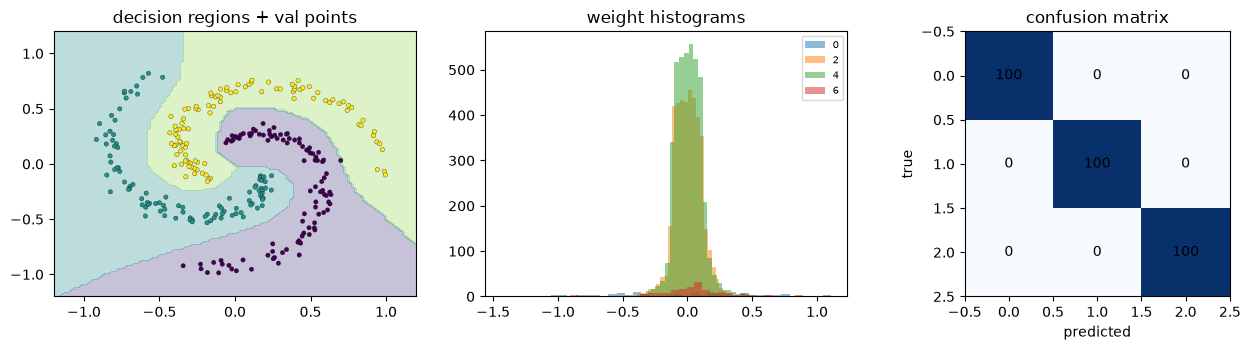

val accuracy: 1.0


In [12]:
torch.manual_seed(0)
model = make_mlp(64, 3)
lg = fit(model, epochs=400, lr=0.1, momentum=0.9)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
# 1. decision boundary
gx, gy = torch.meshgrid(torch.linspace(-1.2, 1.2, 100), torch.linspace(-1.2, 1.2, 100), indexing="xy")
with torch.no_grad(): pred = model(torch.stack([gx.ravel(), gy.ravel()], 1)).argmax(1).view(100, 100)
ax[0].contourf(gx, gy, pred, alpha=0.3, levels=[-0.5, 0.5, 1.5, 2.5]); ax[0].scatter(Xva[:, 0], Xva[:, 1], c=yva, s=10, edgecolor="k", linewidth=0.2)
ax[0].set_title("decision regions + val points")
# 2. weight histograms per layer
for n, p in model.named_parameters():
    if n.endswith("weight"): ax[1].hist(p.detach().flatten().numpy(), bins=40, alpha=0.5, label=n.split(".")[0])
ax[1].set_title("weight histograms"); ax[1].legend(fontsize=7)
# 3. confusion matrix
with torch.no_grad(): vp = model(Xva).argmax(1)
cm = torch.zeros(3, 3, dtype=torch.long)
for t, p_ in zip(yva, vp): cm[t, p_] += 1
ax[2].imshow(cm, cmap="Blues"); ax[2].set_xlabel("predicted"); ax[2].set_ylabel("true"); ax[2].set_title("confusion matrix")
for i in range(3):
    for j in range(3): ax[2].text(j, i, int(cm[i, j]), ha="center", va="center")
plt.tight_layout(); plt.show()
print("val accuracy:", (vp == yva).float().mean().item())

### 13. TensorBoard (optional, guarded)

**What this cell does (plain language):** TensorBoard is the standard live dashboard for scalars, histograms and graphs. It needs the extra `tensorboard` package, so this cell only logs if it is installed and otherwise prints how to install it - the notebook runs either way. Logs go to a temporary directory.

In [13]:
import tempfile
try:
    from torch.utils.tensorboard import SummaryWriter       # raises ImportError if `tensorboard` is missing
    logdir = tempfile.mkdtemp(prefix="tb_demo_")
    writer = SummaryWriter(logdir)
    for step, (tr, va) in enumerate(zip(lg["train"], lg["val"])):
        writer.add_scalars("loss", {"train": tr, "val": va}, step)
    writer.add_histogram("first_layer_weights", model[0].weight.detach(), 0)
    writer.close()
    print("TensorBoard logs written to", logdir, "\nView with:  tensorboard --logdir", logdir)
except ImportError:
    print("TensorBoard not installed. Install with:  pip install tensorboard")
    print("Then log with SummaryWriter(...).add_scalar('loss', value, step) and run: tensorboard --logdir runs")

TensorBoard not installed. Install with:  pip install tensorboard
Then log with SummaryWriter(...).add_scalar('loss', value, step) and run: tensorboard --logdir runs


## Common bugs

- **Judging the model from the training loss only**
  A falling train loss tells you nothing about generalization. Fix: always log validation loss/metric on held-out data and look at the gap.

- **Forgetting `model.eval()` / `torch.no_grad()` for validation**
  Dropout stays active and BatchNorm uses batch statistics, so validation numbers are noisy and pessimistic (and you waste memory building a graph). Fix: `model.eval()` + `with torch.no_grad():`, then `model.train()` again.

- **Hooks never removed**
  Each `register_*hook` returns a handle; forgotten hooks keep running (slowing training, leaking memory by holding tensors) and stack up if you re-register in a notebook cell. Fix: keep the handle and call `.remove()`.

- **Loop-variable capture in hook lambdas**
  `lambda m, i, o: stats[name] = ...` defined in a loop sees the *last* value of `name`. Fix: bind it as a default argument (`name=name`), as in section 7.

- **Smoothing hides real problems**
  A heavily EMA-smoothed curve lags and can hide spikes or divergence. Fix: look at the raw curve alongside the smoothed one.

- **Storing `loss` instead of `loss.item()`**
  Appending the tensor to a list keeps every computation graph alive -> memory growth. Fix: `losses.append(loss.item())` (or `.detach()`).

- **Measuring gradient norm after clipping or after `zero_grad`**
  You then see the clipped value or zeros. Fix: record it after `backward()` and before `clip_grad_norm_`/`zero_grad` (the clip function also *returns* the pre-clip norm).

- **Debugging on the full dataset**
  Slow iteration hides bugs. Fix: shrink to one batch and make it overfit first; only then scale up.

- **Leaving `detect_anomaly(True)` on**
  It slows training several times over. Fix: use it in a narrow `with` block while hunting a NaN, then remove it.

- **Plotting with a linear axis for quantities that span decades**
  Gradient norms and learning-rate sweeps look flat/empty on a linear scale. Fix: `plt.semilogy` or `plt.yscale("log")`.


## Exercises

Attempt each one in the empty cell right after the question. A full solution is in the cell after that - don't peek until you've tried.

**Exercise 1 - Initial loss for C classes.**
A 10-class classifier with a sensible initialization outputs near-uniform probabilities. What is the expected initial cross-entropy? Confirm with a randomly initialized `nn.Linear`.

In [14]:
# Your attempt for Exercise 1 here


**Solution 1**

In [15]:
# Solution 1
print(math.log(10))
torch.manual_seed(0)
lin = nn.Linear(20, 10); xb = torch.randn(512, 20) * 0.1; yb = torch.randint(0, 10, (512,))
print(F.cross_entropy(lin(xb), yb).item())

2.302585092994046
2.304992914199829


**Exercise 2 - Dead ReLU fraction.**
Using a forward hook, compute the fraction of zero activations after the first ReLU of a freshly initialized `make_mlp()` on the training data.

In [16]:
# Your attempt for Exercise 2 here


**Solution 2**

In [17]:
# Solution 2
net = make_mlp(); store = {}
h = net[1].register_forward_hook(lambda m, i, o: store.__setitem__("dead", (o == 0).float().mean().item()))
with torch.no_grad(): net(Xtr)
h.remove(); print(store)

{'dead': 0.39656248688697815}


**Exercise 3 - Gradient norm logger.**
Write `grad_norm_by_layer(model)` that returns {name: grad norm} for all parameters, run it after a backward pass and find the layer with the largest and smallest gradient.

In [18]:
# Your attempt for Exercise 3 here


**Solution 3**

In [19]:
# Solution 3
def grad_norm_by_layer(model):
    return {n: p.grad.norm().item() for n, p in model.named_parameters() if p.grad is not None}
net = make_mlp(depth=4); F.cross_entropy(net(Xtr), ytr).backward()
g = grad_norm_by_layer(net); print(max(g, key=g.get), min(g, key=g.get))

8.weight 0.bias


**Exercise 4 - Early stopping from curves.**
Using `fit` on the overfitting setup (30 points, big model), find the epoch of the minimum validation loss and report how much validation loss increases by the last epoch.

In [20]:
# Your attempt for Exercise 4 here


**Solution 4**

In [21]:
# Solution 4
torch.manual_seed(0)
lg = fit(make_mlp(128, 3), epochs=300, lr=0.05, X=Xtr[::10], y=ytr[::10], momentum=0.9)
best = min(range(len(lg["val"])), key=lg["val"].__getitem__)
print("best epoch", best, "val", round(lg["val"][best], 3), "| final val", round(lg["val"][-1], 3))

best epoch 73 val 0.452 | final val 0.722


**Exercise 5 - Learning-rate range test.**
Increase the learning rate exponentially from 1e-5 to 1 over 100 SGD steps, record the loss and plot it against lr. Pick a good lr (steepest descent, before divergence).

In [22]:
# Your attempt for Exercise 5 here


**Solution 5**

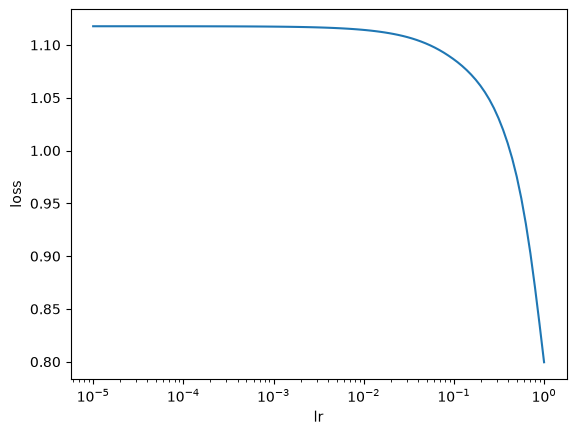

In [23]:
# Solution 5
torch.manual_seed(0)
net = make_mlp(); opt = torch.optim.SGD(net.parameters(), lr=1e-5)
lrs_, losses_ = [], []
for i in range(100):
    lr_i = 1e-5 * (1e5) ** (i / 99)
    for g_ in opt.param_groups: g_["lr"] = lr_i
    opt.zero_grad(); loss = F.cross_entropy(net(Xtr), ytr); loss.backward(); opt.step()
    lrs_.append(lr_i); losses_.append(loss.item())
plt.semilogx(lrs_, losses_); plt.xlabel("lr"); plt.ylabel("loss"); plt.show()

**Exercise 6 - Hook that records activation histograms.**
Register a forward hook that stores the output of the second Linear layer, then plot a histogram of its values with matplotlib.

In [24]:
# Your attempt for Exercise 6 here


**Solution 6**

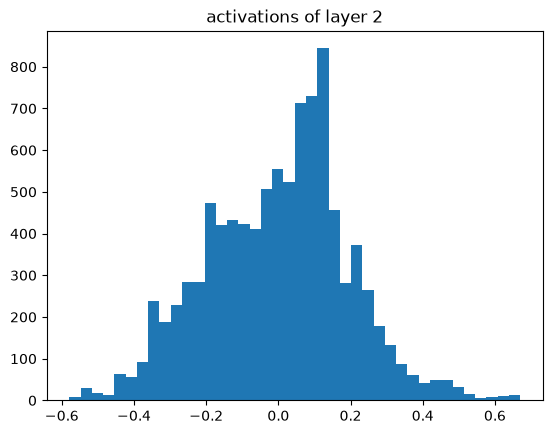

In [25]:
# Solution 6
net = make_mlp(depth=3); saved = []
h = net[2].register_forward_hook(lambda m, i, o: saved.append(o.detach())); net(Xtr); h.remove()
plt.hist(saved[0].flatten().numpy(), bins=40); plt.title("activations of layer 2"); plt.show()

**Exercise 7 - Make a NaN and find it.**
Create a tiny model whose loss becomes NaN because of `torch.log` of a non-positive value, and write a check that identifies it before `backward()`.

In [26]:
# Your attempt for Exercise 7 here


**Solution 7**

In [27]:
# Solution 7
x = torch.tensor([0.5, -1.0, 2.0])
loss = torch.log(x).sum()
print("loss:", loss.item(), "| finite?", torch.isfinite(loss).item())   # False -> stop and inspect inputs

loss: nan | finite? False
